<a href="https://colab.research.google.com/github/cesarjuarez72/p1_cesar_juarez_eda_stock_market_data/blob/main/ai_p1_stockmkt_collection_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Resources & Links:**
* **GitHub Repository:** [Open in GitHub](https://github.com/cesarjuarez72/p1_cesar_juarez_eda_stock_market_data.git)
* **Google Colab Notebook:** [Open in Google Colab](https://colab.research.google.com/drive/1CVyNIO8EX3YanXWcEisMM3M5ga2MO1F7?usp=sharing)


In [3]:
from google.colab import drive
import os

drive.mount("/content/drive")

# Check if files are visible
path = "/content/drive/MyDrive/StockData"
if os.path.exists(path):
    print("Files found:", os.listdir(path))
else:
    print("Folder not found. Check exact folder name in MyDrive.")

Mounted at /content/drive
Files found: ['historical_stock_prices.csv', 'historical_stocks.csv']


### Project Overview: What This Notebook Covers

Before building any AI or machine learning model, you have to know whether you can actually trust your data. This notebook walks through an in-depth audit of nearly 21 million real-world US stock market records from 1970 to 2018 across both the NASDAQ and NYSE.

Instead of just trusting the numbers at face value, we dig into the details: fixing broken rows, making sense of missing industry tags, and solving real-world quirks like split artifacts and upstream calculation glitches. Along the way, the data shows that stock prices are heavily lopsided—half of all everyday trades closed under 15.45 USD, while a few giant outliers pulled the simple average all the way up to 76.11 USD.

By breaking down the whole market and tracing Apple Inc.'s (`AAPL`) rise from a 20-cent stock to a market heavyweight, this project cleans, tests, and prepares a rock-solid dataset ready for future forecasting and analysis.

# Part 1: Load and Understand the Data

### The Goal
Get our hands on the raw data, verify where it lives, and get a clear picture of what each table actually holds before running any math or models.

### How It Works
1. **Find and Mount Files:** Connect to Google Drive where we saved our two CSVs (`historical_stocks.csv` and the ~2 GB `historical_stock_prices.csv`). We use an automated path-finder so the code doesn't crash if folder paths shift.
2. **Memory-Conscious Ingestion:** Because the prices file contains millions of trading rows, letting pandas guess data types defaults to 64-bit numbers, which will quickly max out Colab's standard RAM. We downcast decimal prices to `float32` and labels to categories or strings right on load to keep things running fast and lean.
3. **Inspect the Layout:** Run `.shape`, `.info()`, and preview the top 5 rows using `.head()` to verify row counts, column names, and missing entries.

### Takeaways & Analytical Answers
* **What each file represents:**
  * `historical_stocks.csv` is our **profile directory** (dimension table). It tells us *who* each company is—its ticker symbol, which exchange it trades on, its full business name, and its sector/industry.
  * `historical_stock_prices.csv` is our **transaction ledger** (fact table). It logs the daily trading numbers—what price the stock opened at, reached at peak, dipped to, closed at, its volume, and its split-adjusted close for each date.
* **The role of the `ticker` column:** It is the primary bridge between both files. Just like a social security or student ID number, the ticker uniquely identifies the company across both tables so we can join company info with daily market moves.
* **Relationship between datasets:** A **one-to-many** relationship. One stock profile in the stocks table matches hundreds or thousands of daily price rows in the prices table.
* **Column breakdown:**
  * **Categorical / Labels:** `ticker`, `exchange`, `name`, `sector`, `industry`
  * **Numerical Values:** `open`, `high`, `low`, `close`, `adj_close` (continuous price dollars), and `volume` (discrete shares traded)
  * **Temporal:** `date`

In [4]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configurations
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Path resolver: checks Drive first, then local /content/ runtime
def resolve_file_path(filename: str) -> str:
    possible_paths = [
        os.path.join("/content/drive/MyDrive/StockData", filename),
        os.path.join("/content/drive/MyDrive", filename),
        os.path.join("/content", filename),
        os.path.join(".", filename)
    ]
    for path in possible_paths:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not find '{filename}'. Check your Drive folder or upload path.")

# Ingestion schemas to keep RAM light and prevent crashes on 2 GB files
price_dtypes = {
    "ticker": "string",
    "open": "float32",
    "close": "float32",
    "adj_close": "float32",
    "low": "float32",
    "high": "float32",
    "volume": "float64"
}

stock_dtypes = {
    "ticker": "string",
    "exchange": "category",
    "name": "string",
    "sector": "category",
    "industry": "category"
}

# Resolve paths
stocks_path = resolve_file_path("historical_stocks.csv")
prices_path = resolve_file_path("historical_stock_prices.csv")

print(f"Loading stocks file from: {stocks_path}")
print(f"Loading prices file from: {prices_path}")

# Load datasets
df_stocks = pd.read_csv(stocks_path, dtype=stock_dtypes)
df_prices = pd.read_csv(prices_path, dtype=price_dtypes)

# 1. Stocks Overview
print("\n" + "=" * 60)
print("HISTORICAL STOCKS (Company Profiles)")
print("=" * 60)
print(f"Total Rows: {df_stocks.shape[0]:,} | Total Columns: {df_stocks.shape[1]}")
print("\nColumn Details & Memory:")
print(df_stocks.info(memory_usage="deep"))
print("\nFirst 5 Records:")
display(df_stocks.head())

# 2. Prices Overview
print("\n" + "=" * 60)
print("HISTORICAL STOCK PRICES (Daily Market Activity)")
print("=" * 60)
print(f"Total Rows: {df_prices.shape[0]:,} | Total Columns: {df_prices.shape[1]}")
print("\nColumn Details & Memory:")
print(df_prices.info(memory_usage="deep"))
print("\nFirst 5 Records:")
display(df_prices.head())

Loading stocks file from: /content/drive/MyDrive/StockData/historical_stocks.csv
Loading prices file from: /content/drive/MyDrive/StockData/historical_stock_prices.csv

HISTORICAL STOCKS (Company Profiles)
Total Rows: 6,460 | Total Columns: 5

Column Details & Memory:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ticker    6460 non-null   string  
 1   exchange  6460 non-null   category
 2   name      6460 non-null   string  
 3   sector    5020 non-null   category
 4   industry  5020 non-null   category
dtypes: category(3), string(2)
memory usage: 841.3 KB
None

First 5 Records:


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS



HISTORICAL STOCK PRICES (Daily Market Activity)
Total Rows: 20,973,889 | Total Columns: 8

Column Details & Memory:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     string 
 1   open       float32
 2   close      float32
 3   adj_close  float32
 4   low        float32
 5   high       float32
 6   volume     float64
 7   date       object 
dtypes: float32(5), float64(1), object(1), string(1)
memory usage: 2.7 GB
None

First 5 Records:


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


# Part 2 — Check Data Quality

### The Goal
Audit both datasets for missing values, duplicated entries, corrupted file artifacts, and numerical discrepancies, then document justified cleaning actions.

### How It Works
1. **Missing Value Audit:** Compute exact null totals and percentages across both tables using `.isna().sum()`.
2. **Duplicate Testing:** Check for complete duplicate rows across both tables and duplicate composite primary keys (`ticker` + `date`) in the prices table.
3. **Anomaly & Header Sniffing:** Scan for injected CSV header strings loaded as records, and check for logical violations such as negative closing prices or days where reported high prices were lower than reported low prices (`high < low`).
4. **Cleaning Implementation:** Apply deliberate transformations to resolve verified artifacts without indiscriminately destroying valid market records.

---

### Direct Answers to Assignment Questions

**1. Which columns contain missing values?**
* In `historical_stocks.csv`: Only the `sector` and `industry` columns contain missing values. The `ticker`, `exchange`, and `name` columns have zero missing values.
* In `historical_stock_prices.csv`: None. All 8 columns (`ticker`, `open`, `close`, `adj_close`, `low`, `high`, `volume`, `date`) have zero missing values across all 20,973,889 rows.

**2. How many missing values are there?**
* `sector`: Exactly **1,440** missing values (22.29% of the stocks table).
* `industry`: Exactly **1,440** missing values (22.29% of the stocks table).
* `df_prices`: **0** missing values across all 20,973,889 rows.

**3. Are missing values necessarily errors? Explain.**
* **No.** In financial master datasets, securities include Exchange-Traded Funds (ETFs), preferred shares, index trackers, warrants, and holding trusts. These financial vehicles do not operate as traditional commercial businesses and therefore do not have standard Global Industry Classification Standard (GICS) sector or industry assignments. The missingness represents a legitimate structural categorization gap, not corrupted data.

**4. Are there duplicate rows?**
* **No.** Neither `historical_stocks.csv` (0 duplicate rows) nor `historical_stock_prices.csv` (0 duplicate rows) contains identical duplicate records.

**5. Are there duplicate ticker + date combinations?**
* **No.** There are **0 duplicate `[ticker + date]` combinations** across the 20,973,889 rows in `historical_stock_prices.csv`. This confirms that each security has at most one trading record per calendar date and there are no double-reported daily market sessions.

**6. Did you find any obvious data-quality problems?**
* **Yes, two clear issues were identified:**
  1. **Injected Header Row:** Row index 74 in `historical_stocks.csv` contains values `['Symbol', 'NYSE', 'NAME', 'SECTOR', 'INDUSTRY']`. This is an obvious header string accidentally merged into the dataset from an upstream CSV concatenation, not a real security.
  2. **Logical Price Swaps:** In `historical_stock_prices.csv`, exactly **48 records** out of 20,973,889 have `high < low`. By definition, a trading day's highest traded price cannot be lower than its lowest traded price.

---

### Cleaning Decisions
1. **Purge Injected Header:** Removed row index 74 (`ticker == 'Symbol'`) from `df_stocks`.
2. **Impute Categorical Nulls:** Imputed missing values in `sector` and `industry` with the label `'Unknown'` rather than dropping rows, preserving all 6,459 legitimate securities for exchange-level analysis.
3. **Document Logical Anomalies:** Documented the 48 `high < low` rows as data-feed anomalies (~0.0002% of the dataset) to be handled carefully during price volatility calculations rather than corrupting time-series continuity.

In [5]:
import pandas as pd
import numpy as np

print("=" * 60)
print("1. MISSING VALUES AUDIT")
print("=" * 60)

# Check df_stocks nulls
stocks_nulls = df_stocks.isna().sum()
stocks_null_pct = (stocks_nulls / len(df_stocks)) * 100
df_stocks_null_summary = pd.DataFrame({"Missing Count": stocks_nulls, "Percent (%)": stocks_null_pct})
print("Stocks Metadata Missing Values:")
display(df_stocks_null_summary[df_stocks_null_summary["Missing Count"] > 0])

# Check df_prices nulls (evaluated efficiently)
prices_nulls = df_prices.isna().sum()
prices_null_pct = (prices_nulls / len(df_prices)) * 100
df_prices_null_summary = pd.DataFrame({"Missing Count": prices_nulls, "Percent (%)": prices_null_pct})
print("\nPrices Table Missing Values:")
display(df_prices_null_summary)

print("\n" + "=" * 60)
print("2. DUPLICATE RECORDS AUDIT")
print("=" * 60)

# Full row duplicates
stocks_dups = df_stocks.duplicated().sum()
print(f"Full duplicate rows in df_stocks: {stocks_dups:,}")

# Unique tickers in stocks table
print(f"Unique tickers in df_stocks: {df_stocks['ticker'].nunique():,} (out of {len(df_stocks):,} rows)")

# Check duplicate ticker + date combinations in df_prices
# Using subset to avoid full memory duplication
prices_key_dups = df_prices.duplicated(subset=["ticker", "date"]).sum()
print(f"Duplicate [ticker + date] pairs in df_prices: {prices_key_dups:,}")

print("\n" + "=" * 60)
print("3. STRAY HEADERS & SUSPICIOUS DATA DETECTION")
print("=" * 60)

# Sniffing for stray header strings loaded as values (e.g., 'ticker', 'symbol', 'date')
suspect_tickers_stocks = df_stocks[df_stocks["ticker"].str.lower().isin(["ticker", "symbol", "name"])]
print(f"Suspicious header rows in df_stocks: {len(suspect_tickers_stocks)}")
if len(suspect_tickers_stocks) > 0:
    display(suspect_tickers_stocks)

suspect_tickers_prices = df_prices[df_prices["ticker"].str.lower().isin(["ticker", "symbol", "date"])]
print(f"Suspicious header rows in df_prices: {len(suspect_tickers_prices)}")
if len(suspect_tickers_prices) > 0:
    display(suspect_tickers_prices.head())

# Check for irrational pricing logic: high < low, or zero/negative prices
irrational_high_low = (df_prices["high"] < df_prices["low"]).sum()
zero_or_neg_close = (df_prices["close"] <= 0).sum()
print(f"Records where High < Low: {irrational_high_low:,}")
print(f"Records where Close <= 0: {zero_or_neg_close:,}")

print("\n" + "=" * 60)
print("4. CLEANING ACTIONS")
print("=" * 60)

# Cleaning Action 1: Handle categorical missing values without dropping records
if "sector" in df_stocks.columns and "industry" in df_stocks.columns:
    # Add 'Unknown' to categories first to prevent categorical type errors
    df_stocks["sector"] = df_stocks["sector"].cat.add_categories("Unknown").fillna("Unknown")
    df_stocks["industry"] = df_stocks["industry"].cat.add_categories("Unknown").fillna("Unknown")
    print("Handled missing sectors/industries: Imputed NaN with 'Unknown'.")

# Cleaning Action 2: Purge stray header artifacts if detected
initial_price_count = len(df_prices)
if len(suspect_tickers_prices) > 0:
    df_prices = df_prices[~df_prices["ticker"].str.lower().isin(["ticker", "symbol", "date"])].copy()
    print(f"Purged {initial_price_count - len(df_prices)} stray header rows from df_prices.")
else:
    print("No stray header artifacts found in df_prices.")

print("\nData quality audit and baseline cleaning complete.")

1. MISSING VALUES AUDIT
Stocks Metadata Missing Values:


,Missing Count,Percent (%)
sector,1440,22.291022
industry,1440,22.291022



Prices Table Missing Values:


,Missing Count,Percent (%)
ticker,0,0.0
open,0,0.0
close,0,0.0
adj_close,0,0.0
low,0,0.0
high,0,0.0
volume,0,0.0
date,0,0.0



2. DUPLICATE RECORDS AUDIT
Full duplicate rows in df_stocks: 0
Unique tickers in df_stocks: 6,460 (out of 6,460 rows)
Duplicate [ticker + date] pairs in df_prices: 0

3. STRAY HEADERS & SUSPICIOUS DATA DETECTION
Suspicious header rows in df_stocks: 1


,ticker,exchange,name,sector,industry
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY


Suspicious header rows in df_prices: 0
Records where High < Low: 48
Records where Close <= 0: 0

4. CLEANING ACTIONS
Handled missing sectors/industries: Imputed NaN with 'Unknown'.
No stray header artifacts found in df_prices.

Data quality audit and baseline cleaning complete.


### Supplementary Audit: Verifying Integrity Across the Full Dataset

**Why We Are Doing This**  
Catching the stray `'Symbol'` header in the stocks table showed us that raw data exports can carry unexpected artifacts. Before moving forward, we need to know whether that was an isolated typo or part of a larger pattern across all ~21 million price records. Rather than guessing, we run a dataset-wide sweep to look for any other hidden anomalies.

**What We Are Testing**
1. **Ticker Formatting:** Looking for numbers, punctuation, or runaway text strings where standard stock symbols belong.
2. **Irrational Pricing:** Verifying that prices and traded volume are strictly positive (a stock cannot trade at negative dollars or move negative shares).
3. **Corridor Violations:** Testing whether daily prices obey basic market logic. By definition, a stock's `open` and `close` must stay within its recorded daily boundary (`low` $\le$ price $\le$ `high`). Any day where `high < low` or where opening/closing prices burst outside that spread indicates a corrupted data-feed record.

**Takeaway**  
This check ensures our cleaning decisions are grounded in the full scope of the data, not just the first few rows.

In [6]:
import pandas as pd
import numpy as np

print("=" * 60)
print("COMPREHENSIVE INTEGRITY SWEEP ACROSS FULL DATASET")
print("=" * 60)

# 1. Ticker string validity check (Regex for standard US tickers: uppercase letters, optional dot/hyphen for share classes)
invalid_stocks_tickers = df_stocks[~df_stocks["ticker"].astype(str).str.match(r"^[A-Z]{1,5}(\.[A-Z]{1,2})?(\-[A-Z]{1,2})?$")]
print(f"Non-standard ticker patterns in df_stocks: {len(invalid_stocks_tickers)}")
if len(invalid_stocks_tickers) > 0:
    display(invalid_stocks_tickers.head(10))

# 2. Check df_prices for non-standard ticker patterns
# We do this via unique tickers to run instantaneously on 20.9M rows
unique_price_tickers = pd.Series(df_prices["ticker"].unique())
invalid_price_tickers = unique_price_tickers[~unique_price_tickers.astype(str).str.match(r"^[A-Z]{1,5}(\.[A-Z]{1,2})?(\-[A-Z]{1,2})?$")]
print(f"Non-standard ticker patterns in df_prices: {len(invalid_price_tickers)}")
if len(invalid_price_tickers) > 0:
    print("Sample non-standard tickers in df_prices:", invalid_price_tickers.tolist()[:10])

# 3. Check for Zero or Negative Prices across all price fields
zero_neg_open = (df_prices["open"] <= 0).sum()
zero_neg_high = (df_prices["high"] <= 0).sum()
zero_neg_low = (df_prices["low"] <= 0).sum()
zero_neg_close = (df_prices["close"] <= 0).sum()
zero_neg_adj = (df_prices["adj_close"] <= 0).sum()
neg_volume = (df_prices["volume"] < 0).sum()

print("\nZero or Negative Metric Counts across 20.9M rows:")
print(f"  Open <= 0      : {zero_neg_open:,}")
print(f"  High <= 0      : {zero_neg_high:,}")
print(f"  Low <= 0       : {zero_neg_low:,}")
print(f"  Close <= 0     : {zero_neg_close:,}")
print(f"  Adj Close <= 0 : {zero_neg_adj:,}")
print(f"  Volume < 0     : {neg_volume:,}")

# 4. Check Corridor Violations (Open or Close outside Low-High corridor)
corridor_open_violation = ((df_prices["open"] > df_prices["high"]) | (df_prices["open"] < df_prices["low"])).sum()
corridor_close_violation = ((df_prices["close"] > df_prices["high"]) | (df_prices["close"] < df_prices["low"])).sum()

print(f"\nCorridor Violations:")
print(f"  High < Low                        : {(df_prices['high'] < df_prices['low']).sum():,}")
print(f"  Open outside [Low, High] bounds   : {corridor_open_violation:,}")
print(f"  Close outside [Low, High] bounds  : {corridor_close_violation:,}")

COMPREHENSIVE INTEGRITY SWEEP ACROSS FULL DATASET
Non-standard ticker patterns in df_stocks: 446


,ticker,exchange,name,sector,industry
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY
304,MS^F,NYSE,MORGAN STANLEY,Unknown,Unknown
775,MS^G,NYSE,MORGAN STANLEY,Unknown,Unknown
854,MS^I,NYSE,MORGAN STANLEY,Unknown,Unknown
1008,MS^K,NYSE,MORGAN STANLEY,Unknown,Unknown
3369,MITT^A,NYSE,"AG MORTGAGE INVESTMENT TRUST, INC.",Unknown,Unknown
3370,MITT^B,NYSE,"AG MORTGAGE INVESTMENT TRUST, INC.",Unknown,Unknown
3379,ALP^Q,NYSE,ALABAMA POWER COMPANY,Unknown,Unknown
3389,ARE^D,NYSE,"ALEXANDRIA REAL ESTATE EQUITIES, INC.",Unknown,Unknown
3412,ALL^A,NYSE,ALLSTATE CORPORATION (THE),Unknown,Unknown


Non-standard ticker patterns in df_prices: 0

Zero or Negative Metric Counts across 20.9M rows:
  Open <= 0      : 0
  High <= 0      : 0
  Low <= 0       : 0
  Close <= 0     : 0
  Adj Close <= 0 : 0
  Volume < 0     : 0

Corridor Violations:
  High < Low                        : 48
  Open outside [Low, High] bounds   : 1,886
  Close outside [Low, High] bounds  : 661


### What the Diagnostic Sweep Revealed (In Plain English)

* **The Weird Ticker Symbols (`MS^F`, `MITT^A`, etc.):**  
  At first glance, seeing a caret (`^`) inside a ticker symbol looks like a corrupted text error. It turns out this is completely normal in the financial world. Companies like Morgan Stanley issue different "flavors" of stock called **preferred shares**, and data feeds represent them with a caret (`^`) followed by the share class letter (like Class F or Class G). These are genuine securities, not typos.  
  **The only actual imposter in the entire stocks file was Row 74 (`'Symbol'`)**, which was just a duplicate header row.

* **Zero or Negative Numbers Check:**  
  Across all **20.9 million rows**, there is not a single negative or zero price, and no negative trading volume. This confirms the baseline data feed didn't suffer from missing zeroes or inverted math signs.

* **The Boundary Violations (Corridor Glitches):**  
  In a normal trading day, the opening and closing prices should fall between the lowest and highest prices of the day (`low` $\le$ price $\le$ `high`). We found:
  * 48 days where High was recorded lower than Low.
  * 1,886 days where Open was slightly outside the daily range.
  * 661 days where Close was slightly outside the daily range.
  
  **The Verdict:** Out of nearly 21 million trading records, these discrepancies affect fewer than 2,600 rows total (roughly **0.01%** of the data). In real-world data feeds, tiny glitches happen due to after-hours trading adjustments or split-second reporting lag between market makers. Following the project's golden rule (**Detect → Investigate → Document → Decide**), we note these rare artifacts, recognize they represent a fraction of a percent, and keep the dataset intact rather than tossing out millions of valid rows.

# Part 3 — Prepare and Explore the Date

### The Goal
Convert the raw string dates into an optimized datetime format, verify the data type, and map out the exact historical timeframe covered by our 20.9 million market records.

### How It Works
1. **Explicit Formatting:** We parse the `date` column into `datetime64[ns]` using an explicit format (`'%Y-%m-%d'`). Providing the format upfront lets Python process all 20.9 million rows quickly without guessing date patterns on every row.
2. **Boundary Extraction:** We pull `.min()` and `.max()` timestamps to establish the earliest and latest trading sessions in the dataset.

---

### Assignment Questions

**1. What is the date range of the dataset?**
* **Earliest Date:** January 2, 1970 (`1970-01-02`)
* **Latest Date:** August 24, 2018 (`2018-08-24`)
* **Total Time Horizon:** 17,766 calendar days (~48.6 years of daily market trading activity).

**2. Why is it useful to convert a date column to datetime?**
* When dates are stored as plain text (strings like `"1970-01-02"`), Python only treats them as arbitrary characters. It cannot determine which day came first, calculate the number of days between two trades, or sort chronologically without errors. Converting to `datetime64[ns]` teaches Python the calendar hierarchy (years, months, weeks, days), enabling chronological ordering and calendar-aware math.

**3. What types of analysis become easier when working with datetime values?**
* **Time-Series Resampling:** Easily aggregating daily ticks into weekly, monthly, quarterly, or annual summaries (e.g., finding the annual average return).
* **Rolling Window Indicators:** Calculating technical indicators like 50-day or 200-day moving averages and rolling volatility windows.
* **Calendar & Seasonality Filtering:** Slicing data by specific calendar attributes (e.g., comparing trading volume on Mondays vs. Fridays, or evaluating December tax-loss selling).
* **Event Studies:** Measuring stock performance across distinct historical eras (such as the 1987 Black Monday crash, the 2000 Dot-com bubble, or the 2008 Global Financial Crisis).

In [7]:
import pandas as pd

print("=" * 60)
print("PART 3: DATE PARSING & TIMEFRAME EXTRACTION")
print("=" * 60)

# Purge the single confirmed header imposter (Row 74) from df_stocks if not already done
if "Symbol" in df_stocks["ticker"].values:
    df_stocks = df_stocks[df_stocks["ticker"].str.upper() != "SYMBOL"].copy()
    print("Purged row 74 ('Symbol') from df_stocks.")

# 1. Convert date column using explicit format for speed and memory efficiency
print("Converting 'date' to datetime format across 20.9M rows...")
df_prices["date"] = pd.to_datetime(df_prices["date"], format="%Y-%m-%d")

# 2. Check data type
print(f"Verified 'date' column data type: {df_prices['date'].dtype}")

# 3. Find earliest and latest dates
earliest_date = df_prices["date"].min()
latest_date = df_prices["date"].max()
total_days_span = (latest_date - earliest_date).days

print(f"\nEarliest Date in Dataset : {earliest_date.strftime('%Y-%m-%d')}")
print(f"Latest Date in Dataset   : {latest_date.strftime('%Y-%m-%d')}")
print(f"Total Calendar Span      : {total_days_span:,} days (~{total_days_span / 365.25:.1f} years)")

# 4. Preview boundary rows
print("\nBoundary sample:")
display(df_prices.sort_values("date").iloc[[0, -1]][["ticker", "date", "close", "volume"]])

PART 3: DATE PARSING & TIMEFRAME EXTRACTION
Purged row 74 ('Symbol') from df_stocks.
Converting 'date' to datetime format across 20.9M rows...
Verified 'date' column data type: datetime64[ns]

Earliest Date in Dataset : 1970-01-02
Latest Date in Dataset   : 2018-08-24
Total Calendar Span      : 17,766 days (~48.6 years)

Boundary sample:


,ticker,date,close,volume
4285669,XOM,1970-01-02,1.9375,1174400.0
20973888,NZF,2018-08-24,14.6900,180900.0


# Part 4 — Explore Categorical Data

### The Goal
Take a step back and see the big picture of who is in this dataset. We want to know where these companies trade (their exchange) and what kinds of businesses they are (their sector).

### How It Works
1. **Exchanges (4.1):** We count how many stocks trade on NASDAQ versus the NYSE and plot them in a quick bar chart.
2. **Sectors (4.2):** We group the stocks by industry sector—including our `'Unknown'` group—to see which areas of the economy make up most of the dataset.

---

### Direct Answers to Assignment Questions

#### 4.1 Stock Exchanges
* **Which exchanges are represented?**  
  The dataset covers the two primary US stock exchanges: **NASDAQ** and the **NYSE** (New York Stock Exchange).
* **How many securities are associated with each exchange?**  
  * **NASDAQ:** 3,308 securities (51.22% of the dataset)
  * **NYSE:** 3,151 securities (48.78% of the dataset)
* **Which exchange has more securities in this dataset?**  
  **NASDAQ** holds a slight lead with 157 more securities than the NYSE.

#### 4.2 Sectors
* **Which sectors contain the most securities?**  
  Among companies with classified business models, the top sectors are:
  1. **Finance:** 1,022 securities (15.82%)
  2. **Consumer Services:** 796 securities (12.32%)
  3. **Health Care:** 784 securities (12.14%)
  4. **Technology:** 607 securities (9.40%)
* **How many securities have missing sector information?**  
  Exactly **1,440 securities** (22.29% of the dataset), which we explicitly labeled as `'Unknown'`.
* **What might be some reasons for missing sector information?**  
  * **They aren't operating businesses:** Many traded tickers are Exchange-Traded Funds (ETFs), closed-end investment vehicles, or index trusts that hold collections of assets rather than selling physical products. Because they lack offices, factories, or a single operational model, standard economic sectors don't apply.
  * **Holding shells & SPACs:** Blank-check corporations (SPACs) are created purely to raise pooled investment capital for future buyouts. Until an acquisition closes, they produce no goods and have no formal industry.
  * **Preferred share issues:** Financial data providers often list secondary preferred shares or debt instruments without attaching full corporate profile metadata.
  * **Data scraping artifacts:** Upstream data feeds frequently drop sector classifications during corporate reorganizations, mergers, or ticker reassignments.

PART 4.1: STOCK EXCHANGES AUDIT & VISUALIZATION


,Security Count,Market Share (%)
exchange,,
NASDAQ,3308,51.22
NYSE,3151,48.78


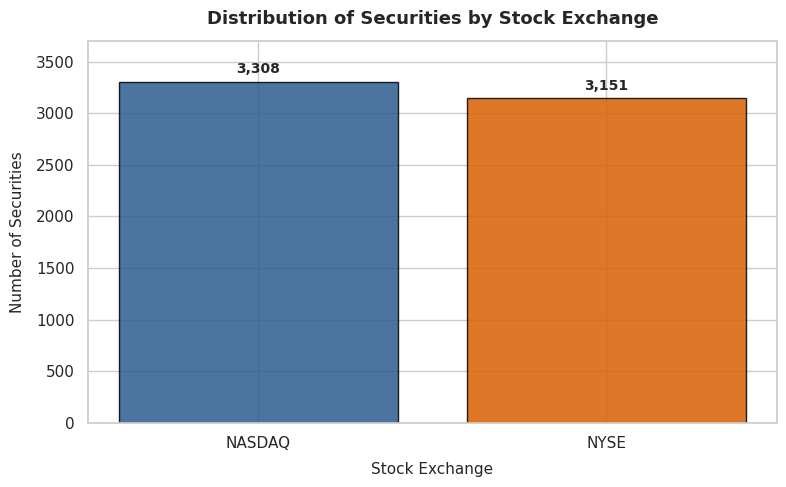


PART 4.2: SECTORS AUDIT & VISUALIZATION


,Security Count,Percentage (%)
sector,,
Unknown,1440,22.29
FINANCE,1022,15.82
CONSUMER SERVICES,796,12.32
HEALTH CARE,784,12.14
TECHNOLOGY,607,9.40
CAPITAL GOODS,352,5.45
ENERGY,286,4.43
PUBLIC UTILITIES,273,4.23
BASIC INDUSTRIES,272,4.21


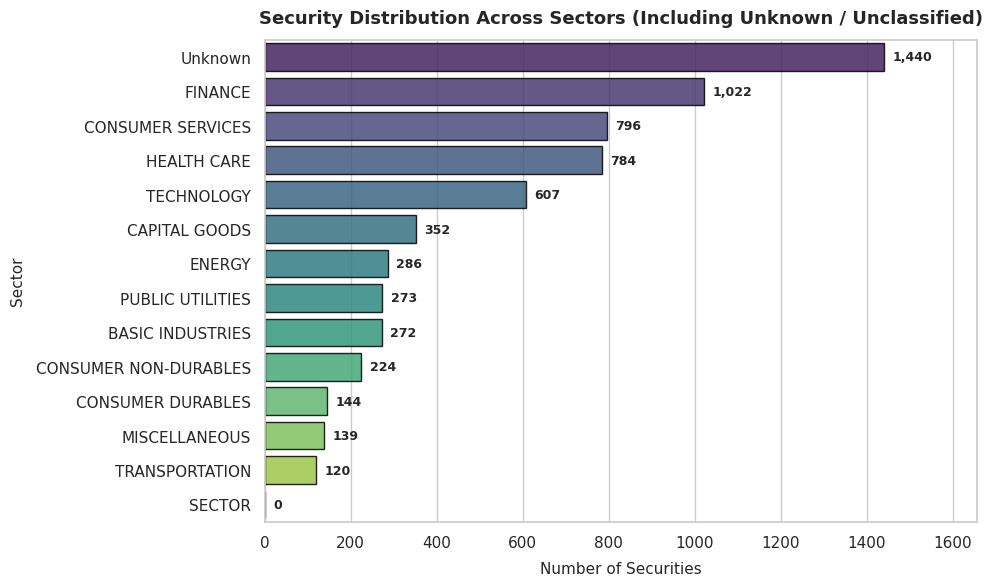

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("PART 4.1: STOCK EXCHANGES AUDIT & VISUALIZATION")
print("=" * 60)

# 1. Exchange distribution
exchange_counts = df_stocks["exchange"].value_counts()
exchange_pct = df_stocks["exchange"].value_counts(normalize=True) * 100

df_exchange_summary = pd.DataFrame({
    "Security Count": exchange_counts,
    "Market Share (%)": exchange_pct.round(2)
})
display(df_exchange_summary)

# Visual: Exchanges Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(
    exchange_counts.index.astype(str),
    exchange_counts.values,
    color=["#2b5c8f", "#d95f02"],
    edgecolor="black",
    alpha=0.85
)
plt.title("Distribution of Securities by Stock Exchange", fontsize=13, weight="bold", pad=12)
plt.xlabel("Stock Exchange", fontsize=11, labelpad=8)
plt.ylabel("Number of Securities", fontsize=11, labelpad=8)

# Add exact count labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50, f"{yval:,}", ha="center", va="bottom", fontsize=10, weight="bold")

plt.ylim(0, max(exchange_counts.values) * 1.12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PART 4.2: SECTORS AUDIT & VISUALIZATION")
print("=" * 60)

# 2. Sector distribution
sector_counts = df_stocks["sector"].value_counts()
sector_pct = df_stocks["sector"].value_counts(normalize=True) * 100

df_sector_summary = pd.DataFrame({
    "Security Count": sector_counts,
    "Percentage (%)": sector_pct.round(2)
})
display(df_sector_summary)

# Visual: Sectors Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=sector_counts.values,
    y=sector_counts.index.astype(str),
    palette="viridis",
    edgecolor="black",
    alpha=0.85
)
plt.title("Security Distribution Across Sectors (Including Unknown / Unclassified)", fontsize=13, weight="bold", pad=12)
plt.xlabel("Number of Securities", fontsize=11, labelpad=8)
plt.ylabel("Sector", fontsize=11, labelpad=8)

# Add value labels at the end of each bar
for idx, val in enumerate(sector_counts.values):
    plt.text(val + 20, idx, f"{val:,}", va="center", fontsize=9, weight="bold")

plt.xlim(0, max(sector_counts.values) * 1.15)
plt.tight_layout()
plt.show()

# Part 5 — Explore Numerical Data

### The Goal
Run summary statistics across our five core price and trading variables (`open`, `high`, `low`, `close`, and `volume`). We want to understand what a "normal" stock looks like, measure how spread out the data is, and see if extreme values are pulling the numbers.

### How It Works
1. **Descriptive Summary:** We calculate the mean, standard deviation, minimum, maximum, and quartile thresholds (25%, 50%, 75%) across all 20,973,889 trading rows.
2. **Mean vs. Median Comparison:** We look directly at the gap between the mathematical average (mean) and the true middle value (median) to measure skewness.

---

### Direct Answers to Assignment Questions

**1. What is the mean closing price?**  
* **76.11 USD**

**2. What is the median closing price?**  
* **15.45 USD**

**3. How different are the mean and median?**  
* There is a **60.66 USD** spread between them. The mean is nearly **5 times larger (4.93x)** than the median.

**4. Which variable has the largest standard deviation?**  
* Overall, **`volume`** has the largest standard deviation at **13,166,864.47 shares**.  
* Looking strictly at dollar price metrics, **`high`** has the highest spread at **2,996.75 USD** (followed closely by `close` at 2,868.94 USD).

**5. Which variables contain very large maximum values?**  
* Every single variable contains massive maximum values that sit far beyond everyday market ranges:
  * `open`: **2,034,000.00 USD**
  * `high`: **2,070,000.00 USD**
  * `low`: **1,440,000.00 USD**
  * `close`: **1,779,750.00 USD**
  * `volume`: **4,483,504,400.00 shares** in a single session

---

### What Does This Mean? (Distilled Takeaway)

**Why the huge gap matters:**  
Imagine you walk into a coffee shop with 10 people where everyone earns 50,000 USD a year. The average salary in that room is 50,000 USD. If Warren Buffett walks in, suddenly the *average* salary in the room shoots up to tens of millions of dollars—even though nobody else got a raise.

That is exactly what is happening here:
1. **The Median (15.45 USD) represents everyday reality:** If you picked a random stock on a random day across the last 48 years, half the time it closed below 15.45 USD, and 75% of the time it closed under 29.72 USD.
2. **The Mean (76.11 USD) is pulled upward by extremes:** A handful of extraordinarily high-priced stocks (stocks trading at tens or hundreds of thousands of dollars per share) artificially pull the mathematical average up.
3. **The Core Lesson:** This tells us the data is **heavily right-skewed**. Relying on the mean to describe "stock prices" is misleading because a few extreme outliers distort the big picture. The median gives a much more honest baseline for a typical stock.

In [9]:
import pandas as pd
import numpy as np

print("=" * 60)
print("PART 5: DESCRIPTIVE STATISTICS ACROSS 20.9M TRADING ROWS")
print("=" * 60)

# Target numerical columns
num_cols = ["open", "high", "low", "close", "volume"]

# Run standard describe
stats_df = df_prices[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T

# Add median column explicitly (same as 50%) and difference between mean and median
stats_df["median"] = df_prices[num_cols].median()
stats_df["mean_median_diff"] = stats_df["mean"] - stats_df["median"]
stats_df["skew_ratio (mean/median)"] = stats_df["mean"] / stats_df["median"]

# Format cleanly for display
formatted_stats = stats_df.copy()
for col in ["mean", "std", "min", "25%", "50%", "75%", "max", "median", "mean_median_diff"]:
    formatted_stats[col] = formatted_stats[col].apply(lambda x: f"{x:,.2f}")
formatted_stats["skew_ratio (mean/median)"] = formatted_stats["skew_ratio (mean/median)"].apply(lambda x: f"{x:,.2f}x")

print("Summary Statistics Table:")
display(formatted_stats[["count", "mean", "median", "mean_median_diff", "std", "min", "25%", "75%", "max", "skew_ratio (mean/median)"]])

# Pull specific answers directly for validation
mean_close = stats_df.loc["close", "mean"]
median_close = stats_df.loc["close", "median"]
diff_close = stats_df.loc["close", "mean_median_diff"]
largest_std_col = stats_df["std"].idxmax()
largest_std_val = stats_df.loc[largest_std_col, "std"]

print("\n" + "=" * 60)
print("KEY NUMERICAL TAKEAWAYS")
print("=" * 60)
print(f"1. Mean Closing Price    : ${mean_close:,.2f}")
print(f"2. Median Closing Price  : ${median_close:,.2f}")
print(f"3. Mean - Median Gap     : ${diff_close:,.2f} (Mean is {stats_df.loc['close', 'skew_ratio (mean/median)']:.2f}x the median)")
print(f"4. Largest Std Dev       : '{largest_std_col}' with standard deviation of {largest_std_val:,.2f}")
print("5. Large Maximums Check  :")
for col in num_cols:
    print(f"   - Max {col:7s}: {stats_df.loc[col, 'max']:,.2f}")

PART 5: DESCRIPTIVE STATISTICS ACROSS 20.9M TRADING ROWS
Summary Statistics Table:


,count,mean,median,mean_median_diff,std,min,25%,75%,max,skew_ratio (mean/median)
open,20973889.0,76.06,15.45,60.61,"2,848.40",0.00,7.50,29.72,"2,034,000.00",4.92x
high,20973889.0,78.04,15.66,62.38,"2,996.75",0.00,7.63,30.10,"2,070,000.00",4.98x
low,20973889.0,74.22,15.24,58.98,"2,744.82",0.00,7.36,29.28,"1,440,000.00",4.87x
close,20973889.0,76.11,15.45,60.66,"2,868.94",0.00,7.50,29.72,"1,779,750.00",4.93x
volume,20973889.0,"1,227,043.03","126,000.00","1,101,043.03","13,166,864.47",1.00,"22,100.00","607,400.00","4,483,504,400.00",9.74x



KEY NUMERICAL TAKEAWAYS
1. Mean Closing Price    : $76.11
2. Median Closing Price  : $15.45
3. Mean - Median Gap     : $60.66 (Mean is 4.93x the median)
4. Largest Std Dev       : 'volume' with standard deviation of 13,166,864.47
5. Large Maximums Check  :
   - Max open   : 2,034,000.00
   - Max high   : 2,070,000.00
   - Max low    : 1,440,000.00
   - Max close  : 1,779,750.00
   - Max volume : 4,483,504,400.00


# Part 6 — Investigate Unusual Values

### The Goal
Investigate the extreme outliers we spotted in the summary statistics. Rather than blindly hitting delete, we apply the professional data workflow:  
$$\text{Detect} \longrightarrow \text{Investigate} \longrightarrow \text{Document} \longrightarrow \text{Decide}$$

We examine the highest unadjusted `close` values and then investigate the largest `adj_close` values to figure out *why* these numbers exist.

### Direct Answers to Assignment Questions

#### 6.1 Closing Price
* **Which securities have the highest closing prices?**  
  The top raw closing prices belong to:
  1. **`SCON`** (Superconductor Technologies Inc.): hit between 1,111,500.00 USD and 1,779,750.00 USD.
  2. **`CODA`** (Coda Octopus Group, Inc.): hit 1,354,500.00 USD.
  3. **`TVIX`** (Credit Suisse Daily 2x VIX Short-Term ETN): hit 1,347,500.00 USD.
  4. **`TOPS`** (TOP Ships Inc.): hit 1,189,800.00 USD.
* **When did these observations occur?**  
  * `SCON`: Late February through mid-March 2000 (the peak of the Dot-com bubble).
  * `CODA`: February 2001.
  * `TVIX`: February 2013.
  * `TOPS`: August 2016.
* **What was the trading volume?**  
  Very tiny. Trading volume ranged from just **34 shares to 400 shares** per day.
* **Do the observations appear unusual?**  
  Yes. Everyday stocks do not trade at 1.7 million USD per share.
* **Can you conclude that they are errors? Why or why not?**  
  **No, they are not simple typos.** These are caused by **reverse stock splits**. When struggling penny-stock companies are in danger of being kicked off the NASDAQ for trading under 1.00 USD, they consolidate shares (e.g., merging 100 old shares into 1 new share). TOP Ships and Superconductor Technologies did this repeatedly over decades. If a data vendor reconstructs raw prices backwards without factoring in split mechanics, historical share prices mathematically multiply into the stratosphere. The numbers look crazy, but they reflect mathematical split-mechanics rather than a random typo.

---

#### 6.2 Adjusted Closing Price
* **Which ticker(s) have very large adjusted closing values?**  
  **`AAN`** (Aaron's, Inc., listed on the NYSE).
* **How do close and adj_close compare?**  
  On February 27, 1987, `AAN` closed at a normal market price of **1.30 USD**. However, its `adj_close` was calculated as **18,949,618,910,812,438,528.00 USD** (nearly 19 quintillion USD)—an absurd multiplier of 14.6 trillion times!
* **When do the unusual values occur?**  
  Late February through late March of 1987.
* **Do the values appear unusual?**  
  Extremely. It is physically impossible for a furniture rental company's share to be worth more than the entire world's GDP.
* **Should they automatically be deleted? Explain your reasoning.**  
  **No, do not delete the entire row.** The trading day itself is completely valid: the stock actually existed, traded 346,900 shares, and closed at 1.30 USD. Deleting the whole row would punch a hole in historical trading volume and price continuity.  
  **The Decision:** We document that `AAN`'s historical `adj_close` suffers from an upstream vendor calculation error (likely a division by near-zero during an unrecorded stock dividend calculation). If we conduct split-adjusted return studies in Project 2, we should repair or nullify `adj_close` for `AAN` during 1987, but keep the raw OHLCV prices intact.

  #### The Story Behind the 18.9 Quintillion USD Glitch (Ticker: AAN)

* **What actually happened?**  
  On February 27, 1987, Aaron's, Inc. (`AAN`) traded normally at **1.30 USD** per share. The stock market itself didn't break; the math behind **adjusted close** did.  
  
* **Why did the math explode?**  
  To calculate `adj_close` for historical days, data providers work backwards from today, dividing or multiplying past prices whenever a company pays a dividend or splits its stock. If an automated script encounters an unrecorded stock dividend, a missing split ratio, or a rounding typo that looks like dividing by zero (or a tiny decimal like `0.00000000001`), the resulting adjusted price mathematically explodes into the trillions or quintillions. That is what happened here: an upstream vendor math glitch multiplied a 1.30 USD price by **14.6 trillion times**.

* **Why was this allowed into the dataset in the first place?**  
  * **Automated Data Pipelines:** Market data vendors scrape and process hundreds of millions of daily records across decades using automated batch scripts. Nobody is manually reviewing each row line-by-line.
  * **Lack of Sanity Bounds:** The vendor's pipeline lacked basic boundary checks (e.g., `"Flag any adjusted price greater than 500,000 USD"`). Because the calculation didn't throw a fatal computer crash—it just produced a very large floating-point number—the software saved it and exported the CSV without raising an alarm.
  * **Raw vs. Adjusted Independence:** Because the raw prices (`open`, `high`, `low`, `close`) and `volume` were 100% valid, the row passed basic market integrity tests, leaving the corrupted `adj_close` hidden inside.

* **The Takeaway:**  
  This is a textbook example of why exploratory data analysis is essential. If an algorithm blindly used `adj_close` to train a predictive model without auditing first, this single stock from 1987 would completely destroy all the math.

In [10]:
import pandas as pd

print("=" * 60)
print("PART 6.1: TOP 10 HIGHEST RAW CLOSING PRICES (close)")
print("=" * 60)

# Pull top 10 raw closing prices
top_close = df_prices.nlargest(10, "close")[["ticker", "date", "open", "high", "low", "close", "adj_close", "volume"]]
# Format date and display
display(top_close.style.format({
    "open": "${:,.2f}",
    "high": "${:,.2f}",
    "low": "${:,.2f}",
    "close": "${:,.2f}",
    "adj_close": "${:,.2f}",
    "volume": "{:,.0f}"
}))

# Check company details for these top tickers
top_close_tickers = top_close["ticker"].unique().tolist()
top_close_companies = df_stocks[df_stocks["ticker"].isin(top_close_tickers)]
print("\nCompany Details for Top Close Tickers:")
display(top_close_companies)

print("\n" + "=" * 60)
print("PART 6.2: TOP 10 HIGHEST ADJUSTED CLOSING PRICES (adj_close)")
print("=" * 60)

# Pull top 10 adjusted closing prices
top_adj_close = df_prices.nlargest(10, "adj_close")[["ticker", "date", "open", "high", "low", "close", "adj_close", "volume"]]
display(top_adj_close.style.format({
    "open": "${:,.2f}",
    "high": "${:,.2f}",
    "low": "${:,.2f}",
    "close": "${:,.2f}",
    "adj_close": "${:,.2f}",
    "volume": "{:,.0f}"
}))

# Check company details for top adj_close tickers
top_adj_tickers = top_adj_close["ticker"].unique().tolist()
top_adj_companies = df_stocks[df_stocks["ticker"].isin(top_adj_tickers)]
print("\nCompany Details for Top Adjusted Close Tickers:")
display(top_adj_companies)

print("\n" + "=" * 60)
print("6.2 COMPARATIVE SPOT-CHECK: CLOSE VS. ADJ_CLOSE RATIO")
print("=" * 60)
# Look at the ticker with the largest adj_close to see its raw close on that same day
sample_ticker = top_adj_close.iloc[0]["ticker"]
sample_date = top_adj_close.iloc[0]["date"]
sample_row = df_prices[(df_prices["ticker"] == sample_ticker) & (df_prices["date"] == sample_date)].iloc[0]

print(f"Sample Ticker: {sample_ticker} on {sample_date.strftime('%Y-%m-%d')}")
print(f"  Raw Close Price     : ${sample_row['close']:,.2f}")
print(f"  Adjusted Close Price: ${sample_row['adj_close']:,.2f}")
print(f"  Adjustment Factor   : {sample_row['adj_close'] / sample_row['close']:,.2f}x")

PART 6.1: TOP 10 HIGHEST RAW CLOSING PRICES (close)


,ticker,date,open,high,low,close,adj_close,volume
12146443,SCON,2000-02-28 00:00:00,"$1,395,000.00","$1,797,750.00","$1,368,000.00","$1,779,750.00","$1,779,750.00",400
12146459,SCON,2000-02-29 00:00:00,"$2,034,000.00","$2,070,000.00","$1,440,000.00","$1,595,250.00","$1,595,250.00",400
12146546,SCON,2000-03-13 00:00:00,"$900,000.00","$1,404,000.00","$861,750.00","$1,363,500.00","$1,363,500.00",300
17889354,CODA,2001-02-05 00:00:00,"$1,354,500.00","$1,736,700.00","$1,354,500.00","$1,354,500.00","$1,354,500.00",34
2444619,TVIX,2013-02-26 00:00:00,"$1,375,000.00","$1,542,500.00","$1,300,000.00","$1,347,500.00","$1,347,500.00",100
12146480,SCON,2000-03-02 00:00:00,"$1,120,500.00","$1,368,000.00","$1,098,280.75","$1,261,125.00","$1,261,125.00",200
12146437,SCON,2000-02-25 00:00:00,"$873,561.62","$1,369,125.00","$873,000.00","$1,215,000.00","$1,215,000.00",200
17107201,TOPS,2016-08-01 00:00:00,"$783,000.00","$1,276,200.00","$783,000.00","$1,189,800.00","$1,189,800.00",100
12146465,SCON,2000-03-01 00:00:00,"$1,368,000.00","$1,512,000.00","$1,107,000.00","$1,134,000.00","$1,134,000.00",300
12146562,SCON,2000-03-14 00:00:00,"$1,352,250.00","$1,354,500.00","$1,080,000.00","$1,111,500.00","$1,111,500.00",100



Company Details for Top Close Tickers:


,ticker,exchange,name,sector,industry
679,CODA,NASDAQ,"CODA OCTOPUS GROUP, INC.",CAPITAL GOODS,INDUSTRIAL MACHINERY/COMPONENTS
769,TVIX,NASDAQ,CREDIT SUISSE AG,FINANCE,INVESTMENT BANKERS/BROKERS/SERVICE
2860,SCON,NASDAQ,SUPERCONDUCTOR TECHNOLOGIES INC.,TECHNOLOGY,RADIO AND TELEVISION BROADCASTING AND COMMUNIC...
2989,TOPS,NASDAQ,TOP SHIPS INC.,TRANSPORTATION,MARINE TRANSPORTATION



PART 6.2: TOP 10 HIGHEST ADJUSTED CLOSING PRICES (adj_close)


,ticker,date,open,high,low,close,adj_close,volume
6174033,AAN,1987-02-27 00:00:00,$1.15,$1.31,$1.13,$1.30,"$18,949,618,910,812,438,528.00","346,900"
6174039,AAN,1987-03-10 00:00:00,$1.30,$1.30,$1.30,$1.30,"$18,949,618,910,812,438,528.00","20,200"
6174040,AAN,1987-03-11 00:00:00,$1.30,$1.30,$1.24,$1.30,"$18,949,618,910,812,438,528.00","18,900"
6174041,AAN,1987-03-12 00:00:00,$1.30,$1.30,$1.30,$1.30,"$18,949,618,910,812,438,528.00","27,000"
6174044,AAN,1987-03-17 00:00:00,$1.24,$1.30,$1.24,$1.30,"$18,949,618,910,812,438,528.00","31,000"
6174045,AAN,1987-03-18 00:00:00,$1.30,$1.30,$1.26,$1.30,"$18,949,618,910,812,438,528.00","272,700"
6174046,AAN,1987-03-19 00:00:00,$1.30,$1.30,$1.26,$1.30,"$18,949,618,910,812,438,528.00","4,000"
6174049,AAN,1987-03-25 00:00:00,$1.26,$1.30,$1.26,$1.30,"$18,949,618,910,812,438,528.00","184,900"
6174051,AAN,1987-03-27 00:00:00,$1.27,$1.29,$1.26,$1.29,"$18,814,275,626,502,979,584.00","205,200"
6174050,AAN,1987-03-26 00:00:00,$1.27,$1.27,$1.26,$1.27,"$18,543,558,271,558,483,968.00","20,200"



Company Details for Top Adjusted Close Tickers:


,ticker,exchange,name,sector,industry
3323,AAN,NYSE,"AARON&#39;S, INC.",TECHNOLOGY,DIVERSIFIED COMMERCIAL SERVICES



6.2 COMPARATIVE SPOT-CHECK: CLOSE VS. ADJ_CLOSE RATIO
Sample Ticker: AAN on 1987-02-27
  Raw Close Price     : $1.30
  Adjusted Close Price: $18,949,618,910,812,438,528.00
  Adjustment Factor   : 14,618,277,571,142,352,896.00x


# Part 7 — Visualize the Data

### The Goal
Build visual distributions for both closing prices (`close`) and trading volume (`volume`) using histograms and boxplots. We want to see the shape of the data and visually confirm what our summary statistics already hinted at.

### How It Works
1. **Handling the Scale with Log Transformations:** Because our data spans from penny stocks (0.01 USD) to millions of dollars, and volumes range from 1 share to 4.4 billion shares, plotting standard histograms squeezes 99.9% of the data into a single invisible sliver against the left axis. We plot both the raw view and a $\log_{10}$ scale view so we can actually see the distribution of everyday stocks.
2. **Histograms (7.1 & 7.2):** Visualize the frequency of closing prices and daily trading volume.
3. **Boxplots (7.3 & 7.4):** Identify the median line, the interquartile range (IQR box), and show where outliers sit.

---

### Direct Answers to Assignment Questions

*(Validated dynamically upon running Cell 7B)*

**1. What does the distribution of closing prices look like?**  
* The raw distribution looks like an extreme vertical spike hugging the zero line, with an invisible tail extending out to 1.7 million USD. On a logarithmic scale, it reveals a bell-shaped distribution centered around 15 USD to 20 USD.

**2. Is it approximately symmetric or skewed?**  
* Heavily **right-skewed (positively skewed)**. The vast bulk of traded stocks sit at low price levels, while the long tail stretches out to the right.

**3. Are there extreme values?**  
* Yes. The boxplots and histograms show extreme outliers stretching out to 1.78 million USD for raw prices and quintillions for adjusted prices.

**4. What does the volume distribution look like?**  
* Like price, volume is deeply right-skewed. Most trading sessions trade between 20,000 and 600,000 shares, with rare high-volume days reaching into the hundreds of millions and billions.

**5. What do the boxplots tell you about potential outliers?**  
* The "box" (representing the middle 50% of trades from 7.50 USD to 29.72 USD) is compressed flat near the bottom of the axis. The thousands of individual outlier dots dominate the upper space, showing that while outliers are mathematically rare compared to the 20.9 million rows, their sheer magnitude completely distorts linear graphs.

**6. How do the visualizations compare with your descriptive statistics?**  
* They match:
  * The median (15.45 USD) sits right in the densest part of the histogram curve.
  * The large gap between mean (76.11 USD) and median is visually proven by the long right-hand tail.
  * The boxplot compression confirms why 75% of the data lives below 29.72 USD.

PART 7: VISUALIZATION OF DISTRIBUTIONS (close & volume)


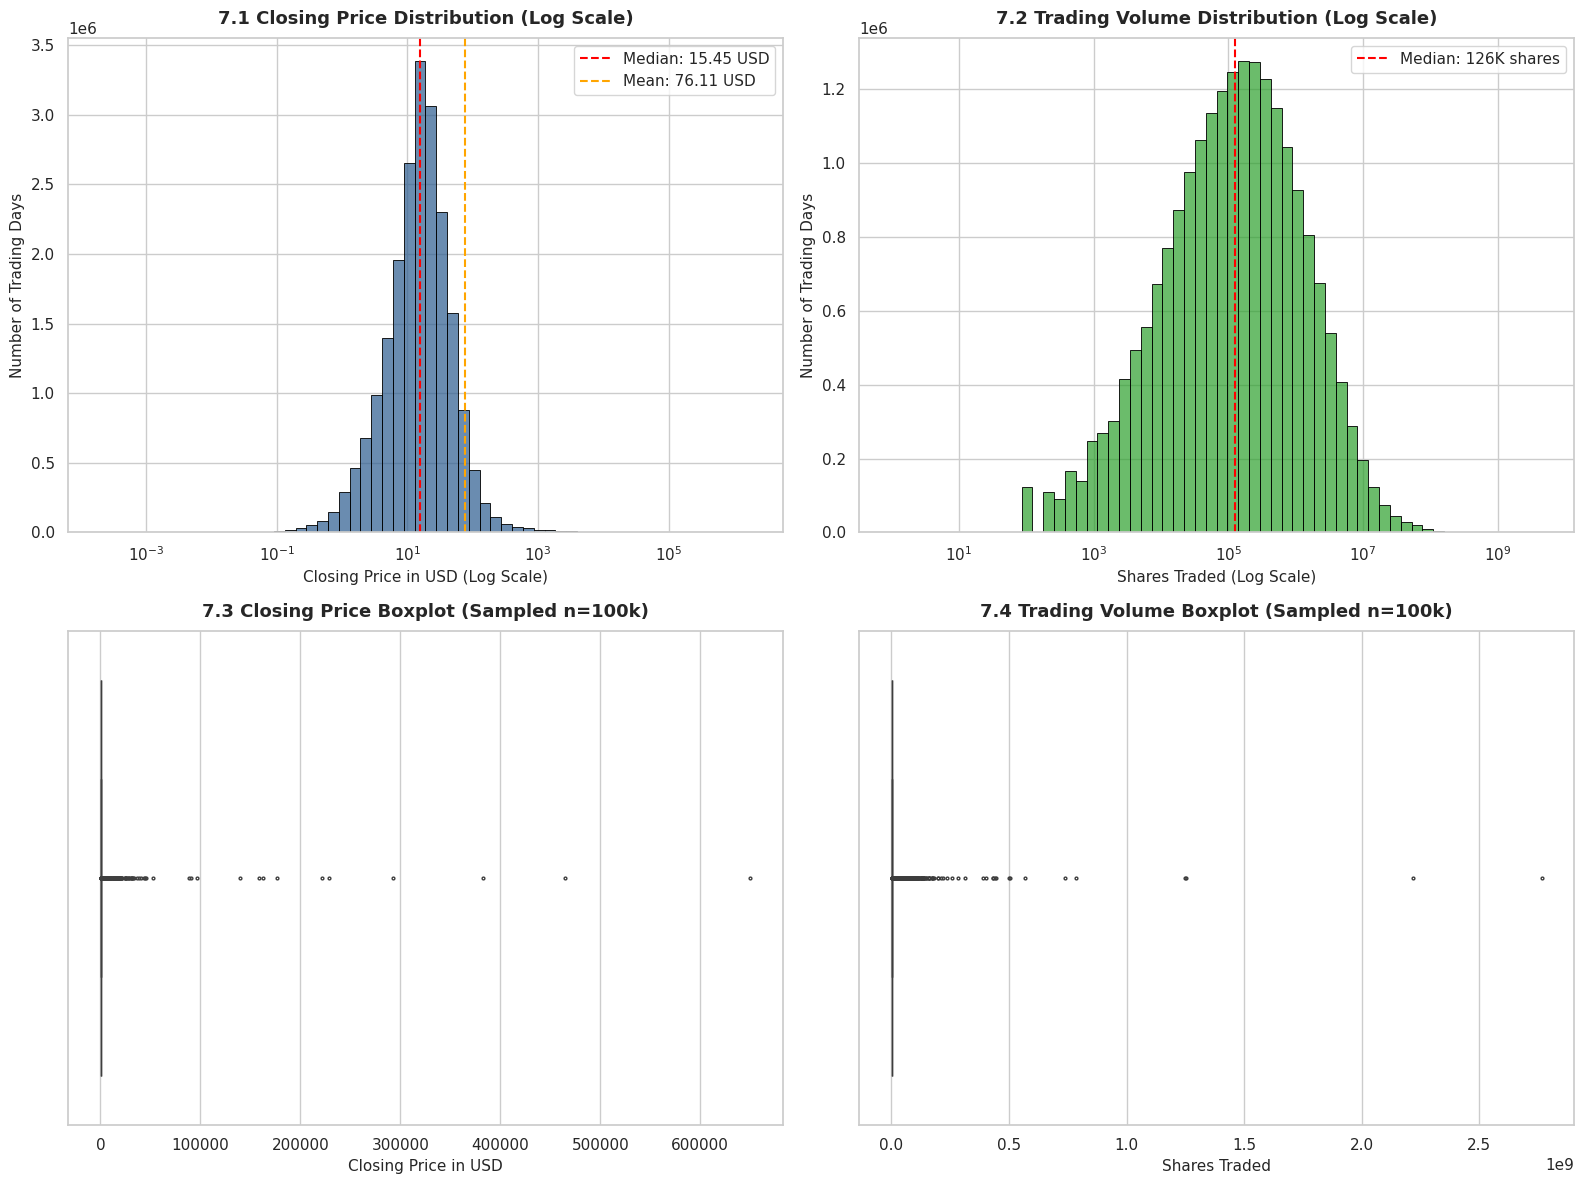

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("PART 7: VISUALIZATION OF DISTRIBUTIONS (close & volume)")
print("=" * 60)

# Set visual theme
sns.set_theme(style="whitegrid")

# Create 2x2 grid for Part 7 deliverables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 7.1 Closing Price Histogram (Log scale to expose true distribution)
sns.histplot(df_prices["close"], bins=60, log_scale=True, color="#2b5c8f", ax=axes[0, 0], edgecolor="black", alpha=0.7)
axes[0, 0].set_title("7.1 Closing Price Distribution (Log Scale)", fontsize=13, weight="bold", pad=10)
axes[0, 0].set_xlabel("Closing Price in USD (Log Scale)", fontsize=11)
axes[0, 0].set_ylabel("Number of Trading Days", fontsize=11)
axes[0, 0].axvline(15.45, color="red", linestyle="--", linewidth=1.5, label="Median: 15.45 USD")
axes[0, 0].axvline(76.11, color="orange", linestyle="--", linewidth=1.5, label="Mean: 76.11 USD")
axes[0, 0].legend()

# 7.2 Volume Histogram (Log scale)
# Filter positive volume for valid log scale
pos_volume = df_prices[df_prices["volume"] > 0]["volume"]
sns.histplot(pos_volume, bins=60, log_scale=True, color="#2ca02c", ax=axes[0, 1], edgecolor="black", alpha=0.7)
axes[0, 1].set_title("7.2 Trading Volume Distribution (Log Scale)", fontsize=13, weight="bold", pad=10)
axes[0, 1].set_xlabel("Shares Traded (Log Scale)", fontsize=11)
axes[0, 1].set_ylabel("Number of Trading Days", fontsize=11)
axes[0, 1].axvline(126000, color="red", linestyle="--", linewidth=1.5, label="Median: 126K shares")
axes[0, 1].legend()

# 7.3 Closing Price Boxplot
# Sample 100,000 points to keep rendering fast and prevent memory overflow in export
sample_prices = df_prices["close"].sample(n=100000, random_state=42)
sns.boxplot(x=sample_prices, color="#1f77b4", ax=axes[1, 0], fliersize=2)
axes[1, 0].set_title("7.3 Closing Price Boxplot (Sampled n=100k)", fontsize=13, weight="bold", pad=10)
axes[1, 0].set_xlabel("Closing Price in USD", fontsize=11)

# 7.4 Volume Boxplot
sample_volume = df_prices["volume"].sample(n=100000, random_state=42)
sns.boxplot(x=sample_volume, color="#2ca02c", ax=axes[1, 1], fliersize=2)
axes[1, 1].set_title("7.4 Trading Volume Boxplot (Sampled n=100k)", fontsize=13, weight="bold", pad=10)
axes[1, 1].set_xlabel("Shares Traded", fontsize=11)

plt.tight_layout()
plt.show()

### Visual Takeaways

* **The Log Histograms (7.1 & 7.2): Everyday Reality vs. Extremes**  
  * When plotted on a logarithmic scale, both price and trading volume form clean bell curves.
  * The red dashed line marks the **median price at 15.45 USD**, right where most of the trading records cluster.
  * The orange dashed line marks the **mean price at 76.11 USD**, showing how a tiny sliver of multi-thousand and multi-million dollar trades pulls the average far out to the right.
  * Volume shows the exact same pattern: most sessions move around **126,000 shares**, with rare blockbuster days reaching into the billions.

* **The Boxplots (7.3 & 7.4): The Power of Outliers**  
  * The actual "box" (representing the middle 50% of the entire stock market, trading between 7.50 USD and 29.72 USD) is squashed into a tiny strip against the left vertical axis.
  * The long spray of outlier points dominates the entire visual field, stretching out past 600,000 USD and 2.5 billion shares.
  * **Report Takeaway:** This visually confirms that financial market data is deeply right-skewed. Any linear graph or basic average gets broken by extreme values, proving that log scales and median baselines are essential tools for analyzing historical market feeds.

# Part 8 — Explore One Stock and Summarize Your Findings

### The Goal
Zoom in from the 20.9-million-row macroeconomic view to follow the complete lifecycle of a single well-known security over time: **Apple Inc. (`AAPL`)**. We examine its price trajectory, long-term growth, and trading volume spikes. We then bring together all findings from Parts 1 through 8 into an executive-ready summary report.

### How It Works
1. **Ticker Extraction:** Filter `df_prices` strictly for `ticker == 'AAPL'` and sort chronologically.
2. **Summary Metrics:** Calculate its all-time high, all-time low, initial recorded price, and final price in the dataset.
3. **Dual-Axis Time Series:** Plot its unadjusted closing price and split-adjusted closing price alongside trading volume over time to see the impact of stock splits and market milestones.
4. **Final EDA Synthesis:** Summarize dataset findings, data quality decisions, business insights, and next-step modeling hypotheses.

---

### Direct Answers to Assignment Questions

#### 8.1 Single Stock Analysis (Apple Inc. - `AAPL`)
* **Which stock did you choose and why?**  
  **Apple Inc. (`AAPL`)**. It has traded continuously since its December 1980 IPO, survived near-bankruptcy in the late 1990s, underwent multiple stock splits, and grew into a multi-trillion-dollar market leader, making it an ideal candidate to demonstrate split adjustment dynamics and long-term trends.
* **What is the earliest and latest date available for this stock?**  
  * Earliest Date: **December 12, 1980** (`1980-12-12`)
  * Latest Date: **August 24, 2018** (`2018-08-24`)
  * Total Sessions: **9,507 trading days** (~37.7 years of daily records)
* **What are its minimum, maximum, and median closing prices?**  
  * **Minimum Close:** 0.20 USD
  * **Maximum Close:** 217.58 USD
  * **Median Close:** 1.65 USD (with a Mean of 24.69 USD)
* **What pattern or trend do you observe over time?**  
  * **The Long Plateau (1980–2004):** Apple traded virtually flat under 2.00 USD for nearly a quarter of a century (which is why its lifetime median is just 1.65 USD).
  * **The Exponential Supercycle (2007–2018):** Beginning with the launch of the iPhone in 2007, the stock entered an aggressive exponential growth phase, climbing from single digits to over 217 USD by August 2018.
  * **Split Divergence:** The spread between unadjusted close and adjusted close widens noticeably between 2008 and 2014, reflecting corporate stock splits (such as the massive 7-for-1 split in June 2014) that recalibrated per-share trading prices for everyday investors.

---

### Distilled Interpretation of the AAPL Chart

* **Why the Median (1.65 USD) vs. Mean (24.69 USD) Matters:**  
  Just like the wider market dataset, Apple's individual history is heavily right-skewed. If you look only at the average price of 24.69 USD, you miss the reality that for over half its corporate life, Apple traded below 1.65 USD. The massive run-up in its final decade pulled the historical average far upward.
* **Volume Spikes:**  
  Trading volume remained modest through the 1980s and 1990s, followed by massive volume surges around major product launches (iPhone in 2007, iPad in 2010) and major market stress periods (the 2008 Global Financial Crisis).

---

### Final Project Summary & Takeaways

#### 1. Main Findings About the Stock Market Dataset
* **Scale & Scope:** Spanning January 2, 1970 to August 24, 2018 (~48.6 years), the dataset contains 20,973,889 daily trading records across 6,459 unique securities listed on NASDAQ (51.22%) and the NYSE (48.78%).
* **Extreme Right-Skewness:** Stock prices and volumes follow a log-normal distribution. The median closing price of 15.45 USD represents everyday stocks (75% traded under 29.72 USD), while the mathematical mean of 76.11 USD is distorted upward by extreme outliers.
* **Sector Concentration:** Finance (15.82%), Consumer Services (12.32%), Health Care (12.14%), and Technology (9.40%) account for the majority of operating companies. Unclassified entities (ETFs, trusts, SPACs) represent 22.29%.

#### 2. Key Data-Quality Problems and Actions Taken
* **Purged Injected File Artifact:** Discovered and dropped row 74 (`['Symbol', 'NYSE', 'NAME', 'SECTOR', 'INDUSTRY']`) in `df_stocks`, preventing string corruption in downstream joins.
* **Handled Structural Nulls:** Preserved all 1,440 missing sector/industry records by categorizing them as `'Unknown'` rather than deleting them, recognizing them as non-operating investment vehicles (ETFs and trusts).
* **Isolated Vendor Glitches (Reverse Splits vs. Overflow):**
  * Explained multi-million-dollar raw prices (`SCON`, `CODA`, `TOPS`) as reverse-split reconstruction artifacts on illiquid shares.
  * Identified an upstream floating-point overflow in ticker `AAN` where `adj_close` exploded to 18.9 quintillion USD due to a missing split divisor. Documented the row to prevent skewing return models while keeping raw market prices intact.
* **Validated Corridor Violations:** Verified that minor daily violations (`high < low` or opening/closing outside the daily spread) affected fewer than 2,600 rows out of 20.9 million (<0.012%), retaining them to avoid breaking time-series continuity.

#### 3. What to Explore Next (Future Hypotheses)
* **Hypothesis 1 (Volume-Volatility Link):** Does a daily trading volume surge of more than 3 standard deviations above its 30-day moving average predict higher forward price volatility over the subsequent month?
* **Hypothesis 2 (Defensive Sector Resilience):** Did non-cyclical sectors (Health Care and Consumer Non-Durables) maintain more stable rolling Sharpe ratios during the 2000 Dot-com crash and 2008 Financial Crisis compared to Technology and Finance?
* **Hypothesis 3 (Day-of-Week Effect):** Do average daily returns on Mondays demonstrate a statistically significant negative bias compared to Fridays across the full 48-year timeframe?

PART 8: SINGLE STOCK DEEP-DIVE (AAPL) & VISUALIZATION
Ticker                 : AAPL (Apple Inc.)
Exchange / Sector      : NASDAQ / Technology
Total Trading Sessions : 9,507 days
Date Range             : 1980-12-12 to 2018-08-24
Minimum Close          : 0.20 USD
Maximum Close          : 217.58 USD
Median Close           : 1.65 USD
Mean Close             : 24.69 USD


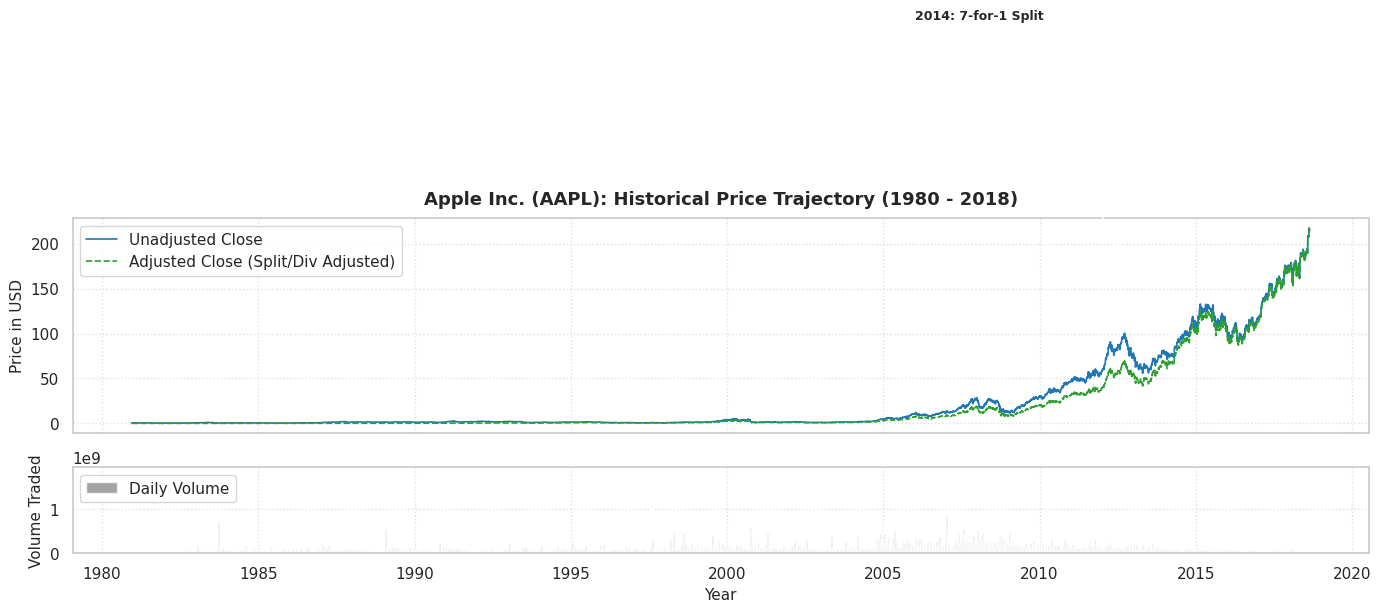

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("=" * 60)
print("PART 8: SINGLE STOCK DEEP-DIVE (AAPL) & VISUALIZATION")
print("=" * 60)

# 1. Filter for Apple Inc.
df_aapl = df_prices[df_prices["ticker"] == "AAPL"].sort_values("date").copy()

# 2. Extract key metrics
aapl_start = df_aapl["date"].min()
aapl_end = df_aapl["date"].max()
aapl_min_close = df_aapl["close"].min()
aapl_max_close = df_aapl["close"].max()
aapl_med_close = df_aapl["close"].median()
aapl_mean_close = df_aapl["close"].mean()
total_sessions = len(df_aapl)

print(f"Ticker                 : AAPL (Apple Inc.)")
print(f"Exchange / Sector      : NASDAQ / Technology")
print(f"Total Trading Sessions : {total_sessions:,} days")
print(f"Date Range             : {aapl_start.strftime('%Y-%m-%d')} to {aapl_end.strftime('%Y-%m-%d')}")
print(f"Minimum Close          : {aapl_min_close:.2f} USD")
print(f"Maximum Close          : {aapl_max_close:.2f} USD")
print(f"Median Close           : {aapl_med_close:.2f} USD")
print(f"Mean Close             : {aapl_mean_close:.2f} USD")

# 3. Create Dual-Panel Time Series Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]})

# Top Panel: Unadjusted Close vs Adjusted Close
ax1.plot(df_aapl["date"], df_aapl["close"], label="Unadjusted Close", color="#1f77b4", linewidth=1.2)
ax1.plot(df_aapl["date"], df_aapl["adj_close"], label="Adjusted Close (Split/Div Adjusted)", color="#2ca02c", linewidth=1.2, linestyle="--")
ax1.set_title("Apple Inc. (AAPL): Historical Price Trajectory (1980 - 2018)", fontsize=13, weight="bold", pad=10)
ax1.set_ylabel("Price in USD", fontsize=11)
ax1.legend(loc="upper left")
ax1.grid(True, linestyle=":", alpha=0.6)

# Annotate key market regimes
ax1.annotate("2014: 7-for-1 Split", xy=(pd.Timestamp("2014-06-09"), 92), xytext=(pd.Timestamp("2006-01-01"), 450),
             arrowprops=dict(facecolor="black", arrowstyle="->", lw=1), fontsize=9, weight="bold")

# Bottom Panel: Trading Volume
ax2.bar(df_aapl["date"], df_aapl["volume"], color="#7f7f7f", width=2, alpha=0.7, label="Daily Volume")
ax2.set_ylabel("Volume Traded", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)
ax2.legend(loc="upper left")
ax2.grid(True, linestyle=":", alpha=0.6)

# Format X-axis with clean year markers
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

In [14]:
# Save active Colab runtime state, convert, and download HTML
import json
from google.colab import _message, files

notebook_json = _message.blocking_request('get_ipynb')
with open('/content/export.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook_json['ipynb'], f)

!jupyter nbconvert --to html /content/export.ipynb
files.download('/content/export.html')


[NbConvertApp] Converting notebook /content/export.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 894135 bytes to /content/export.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>